In [1]:
import pandas as pd
import io

data_string = """
Age_Group,Income_Level,Device_Type,Region,Ad_Clicked,Previous_Purchase,Buy_Product
Young,Low,Mobile,Urban,Yes,No,Yes
Middle,High,Laptop,Urban,Yes,Yes,Yes
Old,Medium,Tablet,Rural,No,No,No
Young,Medium,Mobile,Urban,Yes,Yes,Yes
Middle,Low,Laptop,Suburban,No,No,No
Old,High,Tablet,Rural,Yes,Yes,Yes
Young,Low,Mobile,Suburban,No,No,No
Middle,Medium,Laptop,Urban,Yes,Yes,Yes
Old,Low,Tablet,Rural,No,No,No
Young,High,Mobile,Urban,Yes,Yes,Yes
Middle,Medium,Laptop,Suburban,No,Yes,No
Old,High,Tablet,Urban,Yes,Yes,Yes
Young,Medium,Mobile,Rural,No,No,No
Middle,Low,Laptop,Urban,Yes,No,Yes
Old,Medium,Tablet,Suburban,No,Yes,No
Young,High,Mobile,Urban,Yes,Yes,Yes
Middle,High,Laptop,Rural,No,No,No
Old,Low,Tablet,Suburban,No,No,No
Young,Medium,Mobile,Urban,Yes,No,Yes
Middle,Medium,Laptop,Urban,Yes,Yes,Yes
"""

df = pd.read_csv(io.StringIO(data_string))
print(df.head())

  Age_Group Income_Level Device_Type    Region Ad_Clicked Previous_Purchase  \
0     Young          Low      Mobile     Urban        Yes                No   
1    Middle         High      Laptop     Urban        Yes               Yes   
2       Old       Medium      Tablet     Rural         No                No   
3     Young       Medium      Mobile     Urban        Yes               Yes   
4    Middle          Low      Laptop  Suburban         No                No   

  Buy_Product  
0         Yes  
1         Yes  
2          No  
3         Yes  
4          No  


In [2]:
display(df)

,Age_Group,Income_Level,Device_Type,Region,Ad_Clicked,Previous_Purchase,Buy_Product
0,Young,Low,Mobile,Urban,Yes,No,Yes
1,Middle,High,Laptop,Urban,Yes,Yes,Yes
2,Old,Medium,Tablet,Rural,No,No,No
3,Young,Medium,Mobile,Urban,Yes,Yes,Yes
4,Middle,Low,Laptop,Suburban,No,No,No
5,Old,High,Tablet,Rural,Yes,Yes,Yes
6,Young,Low,Mobile,Suburban,No,No,No
7,Middle,Medium,Laptop,Urban,Yes,Yes,Yes
8,Old,Low,Tablet,Rural,No,No,No
9,Young,High,Mobile,Urban,Yes,Yes,Yes


In [ ]:
# for categorical data
# problem statemnt
# Predict whether a customer will Buy_Product based on multiple categorical features.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
X = df.drop(columns=['Buy_Product'])
y = df['Buy_Product']

In [15]:
from sklearn.preprocessing import LabelEncoder

X_encoded = pd.get_dummies(X)

# Label encode y (target variable)
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [18]:
X_train , X_test , y_train , y_test = train_test_split(X_encoded , y_encoded , test_size=0.2 , random_state=42)

In [53]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

In [8]:
clf = CategoricalNB()

In [19]:
clf.fit(X_train,y_train)

CategoricalNB()

In [21]:
y_pred = clf.predict(X_test)

In [23]:
confusion_matrix(y_test,y_pred)

array([[1, 0],
       [0, 3]])

In [26]:
data_string = """
Study_Hours,Attendance,Assignments_Score,Sleep_Hours,Mock_Test_Score,Pass_Exam
2,55,45,5,40,No
8,90,88,7,85,Yes
6,80,75,6,70,Yes
1,40,30,4,25,No
7,85,82,7,78,Yes
3,60,50,5,45,No
9,95,92,8,90,Yes
4,70,65,6,60,Yes
2,50,35,5,30,No
8,88,85,7,82,Yes
5,75,70,6,68,Yes
1,35,20,4,15,No
7,82,80,7,76,Yes
3,58,48,5,42,No
9,96,95,8,93,Yes
4,68,60,6,55,No
6,78,72,6,69,Yes
2,45,38,5,32,No
8,91,89,7,87,Yes
5,72,67,6,63,Yes
"""

df2 = pd.read_csv(io.StringIO(data_string))

In [27]:
df2

,Study_Hours,Attendance,Assignments_Score,Sleep_Hours,Mock_Test_Score,Pass_Exam
0,2,55,45,5,40,No
1,8,90,88,7,85,Yes
2,6,80,75,6,70,Yes
3,1,40,30,4,25,No
4,7,85,82,7,78,Yes
5,3,60,50,5,45,No
6,9,95,92,8,90,Yes
7,4,70,65,6,60,Yes
8,2,50,35,5,30,No
9,8,88,85,7,82,Yes


In [57]:
y = df2.iloc[:,5:]
X = df2.iloc[:,[0,4]]

In [59]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [60]:
X_train , X_test , y_train , y_test = train_test_split(X,y_encoded,test_size=0.2,random_state=42)

In [61]:
from sklearn.naive_bayes import GaussianNB

In [62]:
clf2 = GaussianNB()

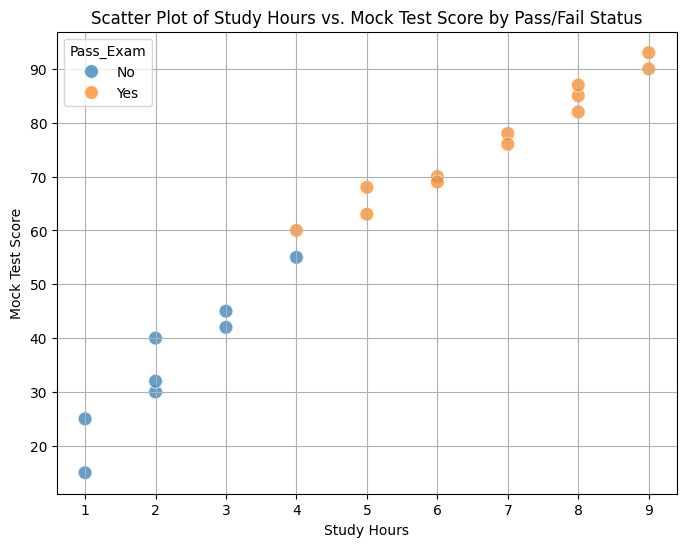

In [63]:
import seaborn as sns

# Combine features and target for plotting
df_plot = pd.concat([X, df2['Pass_Exam']], axis=1)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_plot, x='Study_Hours', y='Mock_Test_Score', hue='Pass_Exam', s=100, alpha=0.7)
plt.title('Scatter Plot of Study Hours vs. Mock Test Score by Pass/Fail Status')
plt.xlabel('Study Hours')
plt.ylabel('Mock Test Score')
plt.grid(True)
plt.show()

In [65]:
clf2.fit(X_train, y_train)

GaussianNB()

In [66]:
y_pred = clf2.predict(X_test)

In [67]:
confusion_matrix(y_test, y_pred, labels=[1,0])
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



In [68]:
accuracy_score(y_test,y_pred)

0.75

In [55]:
# ### Why Gaussian Naive Bayes might not be performing great:

# Gaussian Naive Bayes (GNB) makes two key assumptions that, if violated by your data, can impact its performance:

# 1.  **Gaussian Distribution Assumption**: GNB assumes that the continuous features for each class are distributed according to a Gaussian (normal) distribution. If your features (like 'Study_Hours' or 'Mock_Test_Score') within the 'Pass_Exam' categories are significantly skewed, multimodal, or follow other non-Gaussian distributions, the model's estimation of class-conditional probabilities will be inaccurate.
# 2.  **Conditional Independence Assumption**: GNB assumes that all features are conditionally independent of each other, given the class label. In real-world scenarios, this assumption is often violated. For example, 'Study_Hours' and 'Mock_Test_Score' are likely positively correlated; more study hours often lead to higher mock test scores. While Naive Bayes can be surprisingly robust to this violation, strong correlations can sometimes reduce its accuracy.
# 3.  **Small Dataset Size**: With a very small dataset (like your `df2` with only 20 samples), accurately estimating the mean and standard deviation for the Gaussian distribution of each feature within each class can be challenging and lead to less reliable parameter estimates, which can affect the model's generalization performance.

# ### Which Naive Bayes model should you use?

# Given that your `df2` dataset consists of continuous numerical features, `GaussianNB` is the standard and often the most appropriate choice among the Naive Bayes family. However, if you suspect the Gaussian distribution assumption is severely violated, consider these approaches:

# 1.  **Feature Transformation**: You could try transforming your continuous features to make them more Gaussian-like. Common transformations include:
#     *   **Log Transformation**: For right-skewed data.
#     *   **Square Root Transformation**: Also for right-skewed data.
#     *   **Box-Cox Transformation**: A more general power transformation that can handle various types of non-normal distributions.
# 2.  **Discretization**: Convert your continuous features into categorical bins. Once discretized, you could then use `CategoricalNB` (as you did with your first dataset). However, this approach has the drawback of losing some information present in the continuous values and can be sensitive to how the bins are defined.

In [56]:
# lets to feaature selection and standarisation and normalisation to see the new results
from sklearn.preprocessing import Normalizer , StandardScaler , MinMaxScaler

In [69]:
y = df2.iloc[:,5:]
X = df2.iloc[:,[0,4]]

In [72]:
normalzer = Normalizer()
X_normalized = normalzer.fit_transform(X)

In [73]:
X_normalized

array([[0.04993762, 0.99875234],
       [0.09370354, 0.99560014],
       [0.08540114, 0.99634665],
       [0.03996804, 0.99920096],
       [0.08938436, 0.99599721],
       [0.06651901, 0.99778516],
       [0.09950372, 0.99503719],
       [0.06651901, 0.99778516],
       [0.06651901, 0.99778516],
       [0.09709996, 0.99527463],
       [0.07333144, 0.99730763],
       [0.06651901, 0.99778516],
       [0.09171705, 0.99578511],
       [0.07124705, 0.9974587 ],
       [0.09632419, 0.99535001],
       [0.0725357 , 0.99736582],
       [0.08662962, 0.99624059],
       [0.06237829, 0.99805258],
       [0.09156771, 0.99579885],
       [0.0791163 , 0.99686539]])

In [74]:
X_train , X_test , y_train , y_test = train_test_split(X_normalized,y_encoded,test_size=0.2,random_state=42)

In [75]:
clf3 = GaussianNB()
clf3.fit(X_train,y_train)

GaussianNB()

In [76]:
clf3.score(X_test,y_test)

1.0

In [77]:
y_pred = clf3.predict(X_test)

In [80]:
accuracy_score(y_test,y_pred)

1.0

In [82]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[3 0]
 [0 1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [84]:
rng = np.random.RandomState(1)
X = rng.randint(5, size=(6, 100))
Y = np.array([1, 2, 3, 4, 4, 5])
from sklearn.naive_bayes import BernoulliNB
clf = BernoulliNB()
clf.fit(X, Y)

BernoulliNB()

In [90]:
print(clf.predict(X[2:3]))

[4]


array([1, 2, 3, 4, 4, 5])